# Laptop Price (Regression Task) 💻
1. Data Loading & First Look
2. Exploratory Data Analysis (EDA)
3. Data Cleaningstrategy you chose (e.g., why mean vs. median imputation).
4. Preprocessing
5. Dimensionality Reduction (PCA)
6. Modeling
7. Evaluation
8. Conclusion

# 0. Setup ⚒

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings

# 1. Data Loading & First Look 📂

In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("ehtishamsadiq/uncleaned-laptop-price-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'uncleaned-laptop-price-dataset' dataset.
Path to dataset files: /kaggle/input/uncleaned-laptop-price-dataset


In [3]:
print(os.listdir(path))

['laptopData.csv']


In [4]:
df = pd.read_csv(f'{path}/laptopData.csv')
rows, cols = df.shape
print(f'data has been downloaded successfully, shape: {rows} rows, {cols} columns.\nFirst 5 rows:')
df.head()

data has been downloaded successfully, shape: 1303 rows, 12 columns.
First 5 rows:


,Unnamed: 0,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price
0,0.0,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8GB,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37kg,71378.6832
1,1.0,Apple,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8GB,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34kg,47895.5232
2,2.0,HP,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8GB,256GB SSD,Intel HD Graphics 620,No OS,1.86kg,30636.0000
3,3.0,Apple,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16GB,512GB SSD,AMD Radeon Pro 455,macOS,1.83kg,135195.3360
4,4.0,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8GB,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37kg,96095.8080


# 2. Exploratory Data Analysis (EDA) 🔎
### 2.1. check genral info and data types

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1303 entries, 0 to 1302
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Unnamed: 0        1273 non-null   float64
 1   Company           1273 non-null   object 
 2   TypeName          1273 non-null   object 
 3   Inches            1273 non-null   object 
 4   ScreenResolution  1273 non-null   object 
 5   Cpu               1273 non-null   object 
 6   Ram               1273 non-null   object 
 7   Memory            1273 non-null   object 
 8   Gpu               1273 non-null   object 
 9   OpSys             1273 non-null   object 
 10  Weight            1273 non-null   object 
 11  Price             1273 non-null   float64
dtypes: float64(2), object(10)
memory usage: 122.3+ KB


In [6]:
df.describe()

,Unnamed: 0,Price
count,1273.000000,1273.000000
mean,652.674784,59955.814073
std,376.493027,37332.251005
min,0.000000,9270.720000
25%,327.000000,31914.720000
50%,652.000000,52161.120000
75%,980.000000,79333.387200
max,1302.000000,324954.720000


From the two cells above, we have to deal with each column differently ( categoral and numerical ) since there are only 2 numerical columns

In [7]:
df.describe(include="all")

,Unnamed: 0,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price
count,1273.000000,1273,1273,1273,1273,1273,1273,1273,1273,1273,1273,1273.000000
unique,NaN,19,6,25,40,118,10,40,110,9,189,NaN
top,NaN,Lenovo,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8GB,256GB SSD,Intel HD Graphics 620,Windows 10,2.2kg,NaN
freq,NaN,290,710,640,495,183,601,401,271,1047,111,NaN
mean,652.674784,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,59955.814073
std,376.493027,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,37332.251005
min,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9270.720000
25%,327.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,31914.720000
50%,652.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,52161.120000
75%,980.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,79333.387200


In [8]:
# the column 'Unnamed: 0' is just for numbering the rows so just drop it
df=df.drop(columns='Unnamed: 0')
df.columns

Index(['Company', 'TypeName', 'Inches', 'ScreenResolution', 'Cpu', 'Ram',
       'Memory', 'Gpu', 'OpSys', 'Weight', 'Price'],
      dtype='object')

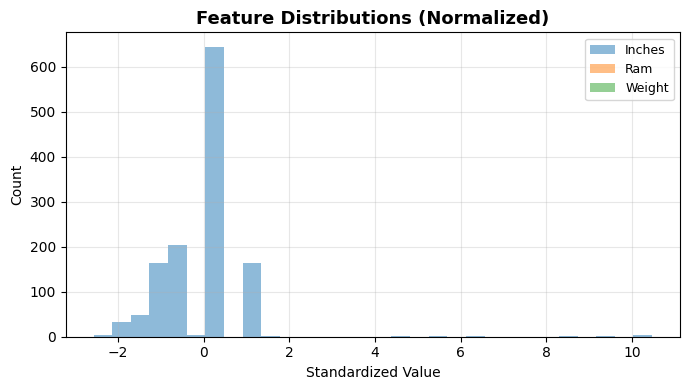

In [9]:
# --- Plot : Distribution Feature ---
plt.figure(figsize=(7, 4))
num_features = ['Inches', 'Ram', 'CpuGHz', 'Weight', 'MemoryGB']
for col in num_features:
    if col in df.columns:
        vals = pd.to_numeric(df[col], errors='coerce').dropna()
        vals_norm = (vals - vals.mean()) / vals.std()
        plt.hist(vals_norm, bins=30, alpha=0.5, label=col, edgecolor='none')
plt.title('Feature Distributions (Normalized)', fontsize=13, fontweight='bold')
plt.xlabel('Standardized Value')
plt.ylabel('Count')
plt.legend(fontsize=9)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 2.2. Check for null values

In [10]:
# check for missiness in columns
missing = df.isnull().sum()
print('Missing values per row:\n',missing,'\n\nMissing in DataFrame:')
df[df.isnull().any(axis=1)]

Missing values per row:
 Company             30
TypeName            30
Inches              30
ScreenResolution    30
Cpu                 30
Ram                 30
Memory              30
Gpu                 30
OpSys               30
Weight              30
Price               30
dtype: int64 

Missing in DataFrame:


,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price
20,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
46,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
115,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
125,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
148,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
190,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
209,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
267,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
336,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [11]:
# Since the whole row is NaN, I wouldn't impute them, dropping them is fine
df = df.dropna(axis=0)

In [12]:
# check for remaining null values
df.isnull().sum()

,0
Company,0
TypeName,0
Inches,0
ScreenResolution,0
Cpu,0
Ram,0
Memory,0
Gpu,0
OpSys,0
Weight,0


### 2.3 Duplicated columns

In [13]:
# check for number of duplicated rows
print(df.duplicated().sum())
df[df.duplicated()]

29


,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price
1274,Asus,Notebook,15.6,1366x768,Intel Celeron Dual Core N3050 1.6GHz,4GB,500GB HDD,Intel HD Graphics,Windows 10,2.2kg,19660.3200
1275,Asus,Ultrabook,13.3,IPS Panel Full HD 1920x1080,Intel Core M 6Y30 0.9GHz,8GB,512GB SSD,Intel HD Graphics 515,Windows 10,1.2kg,38841.1200
1276,Dell,Notebook,15.6,1366x768,Intel Core i3 7100U 2.4GHz,6GB,1TB HDD,Intel HD Graphics 620,Windows 10,2.3kg,24455.5200
1277,Acer,Notebook,15.6,1366x768,Intel Celeron Dual Core N3060 1.6GHz,4GB,500GB HDD,Intel HD Graphics 400,Linux,2.4kg,15397.9200
1278,Dell,Notebook,15.6,1366x768,Intel Celeron Dual Core N3050 1.6GHz,2GB,500GB HDD,Intel HD Graphics,Windows 10,2.20kg,20193.1200
1279,Lenovo,Notebook,15.6,IPS Panel Full HD 1920x1080,Intel Core i7 6700HQ 2.6GHz,8GB,1TB HDD,Nvidia GeForce GTX 960M,Windows 10,2.6kg,47898.7200
1280,HP,Notebook,15.6,Full HD 1920x1080,AMD A9-Series 9410 2.9GHz,6GB,1.0TB Hybrid,AMD Radeon R7 M440,Windows 10,2.04kg,29303.4672
1281,Dell,Notebook,15.6,1366x768,Intel Core i7 7500U 2.7GHz,8GB,1TB HDD,AMD Radeon R5 M430,Linux,2.3kg,42943.1472
1282,HP,Netbook,11.6,1366x768,Intel Celeron Dual Core N3060 1.6GHz,2GB,32GB Flash Storage,Intel HD Graphics 400,Windows 10,1.17kg,11135.5200
1283,Asus,Notebook,15.6,1366x768,Intel Core i7 6500U 2.5GHz,4GB,500GB HDD,Nvidia GeForce 920M,Windows 10,2.2kg,38378.6496


In [14]:
# drop the duplicated rows then recheck
df = df.drop_duplicates()
print(df.duplicated().sum())

0


# 3. Feature engineering

### 3.1. column `Inches`:

In [15]:
df['Inches'].unique()

array(['13.3', '15.6', '15.4', '14', '12', '17.3', '13.5', '12.5', '13',
       '18.4', '13.9', '11.6', '25.6', '35.6', '12.3', '27.3', '24',
       '33.5', '?', '31.6', '17', '15', '14.1', '11.3', '10.1'],
      dtype=object)

In [16]:
# one value contains '?', so I replaced it with nan first then converted the type of that column
# the imputed that value with the median because it's robust to outliers
df['Inches'] = df['Inches'].replace('?',np.nan)
df['Inches'] = df['Inches'].astype(float)
df['Inches']=df['Inches'].fillna(df['Inches'].median())

In [17]:
# I noticeed that there are some inconsistent values, so I will start to investegate
print('Percentage of that outlier:',round(len(df[df["Inches"] > 20])/len(df["Inches"])*100,2),'%','\nNumber of inconsistent Values:',len(df[df["Inches"] > 20]),'Number of all the rows',len(df["Inches"]))

Percentage of that outlier: 0.72 % 
Number of inconsistent Values: 9 Number of all the rows 1244


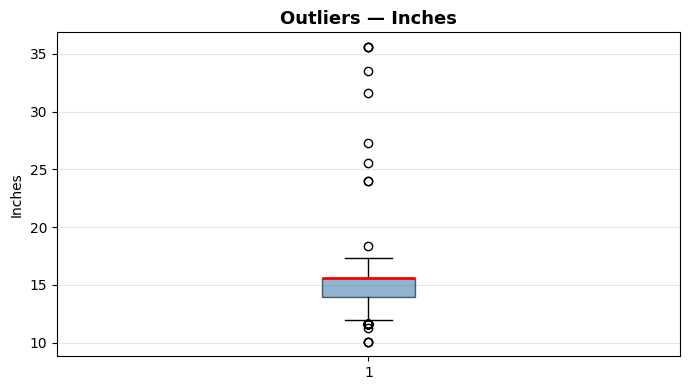

In [18]:
# --- Plot : Outliers Inches ---
plt.figure(figsize=(7, 4))
plt.boxplot(df['Inches'], vert=True, patch_artist=True,
            boxprops=dict(facecolor='steelblue', alpha=0.6),
            medianprops=dict(color='red', linewidth=2),
            flierprops=dict(marker='o', color='coral', markersize=6))
plt.title('Outliers — Inches', fontsize=13, fontweight='bold')
plt.ylabel('Inches')
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

In [19]:
# Here I printed the inconsistent rows to learn more
df[df["Inches"] > 20]

,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price
402,Lenovo,Notebook,25.6,IPS Panel Full HD 1920x1080,Intel Core i5 8250U 1.6GHz,8GB,256GB SSD + 1TB HDD,AMD Radeon RX 550,Windows 10,2.1kg,60978.96
408,Lenovo,Notebook,35.6,Full HD 1920x1080,Intel Core i3 6006U 2GHz,4GB,500GB HDD,Intel HD Graphics 520,Windows 10,2.2kg,21791.52
423,Asus,Notebook,35.6,Full HD 1920x1080,Intel Core i3 7100U 2.4GHz,8GB,1TB HDD,Nvidia GeForce 940MX,Linux,2.3kg,31808.16
424,Dell,Gaming,27.3,IPS Panel 2560x1440,Intel Core i7 7820HK 2.9GHz,16GB,256GB SSD + 1TB HDD,Nvidia GeForce GTX 1070,Windows 10,4.42kg,149130.72
438,Lenovo,Ultrabook,24.0,2560x1440,Intel Core i7 7500U 2.7GHz,24GB,512GB SSD,Intel HD Graphics 620,Windows 10,1.32kg,126912.96
458,Microsoft,Ultrabook,33.5,Touchscreen 2256x1504,Intel Core i7 7660U 2.5GHz,8GB,256GB SSD,Intel Iris Plus Graphics 640,Windows 10 S,1.25kg,95850.72
525,Lenovo,Notebook,24.0,Full HD 1920x1080,Intel Core i5 6200U 2.3GHz,8GB,256GB SSD,Intel HD Graphics 520,Windows 7,2.02kg,71395.20
592,Dell,2 in 1 Convertible,31.6,Touchscreen 1366x768,Intel Core M 7Y30 1.0GHz,4GB,128GB SSD,Intel HD Graphics 615,Windows 10,1.39kg,32127.84
673,Lenovo,Notebook,35.6,1366x768,AMD E-Series E2-9000 2.2GHz,4GB,128GB SSD,AMD Radeon R2 Graphics,Windows 10,2.2kg,18594.72


###🔍 In the cell above I noticed that non of the columns with extemely large number of inches are consistent with their weights

In [20]:
# so I continued investegating and noticed that there is a pattern all the values end with '.5' and all of them have similar
# weights, so I concluded that it's an Data Entry Error
df[df["Company"] == "Microsoft"]

,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price
70,Microsoft,Ultrabook,13.5,Touchscreen 2256x1504,Intel Core i5 7200U 2.5GHz,4GB,128GB SSD,Intel HD Graphics 620,Windows 10 S,1.252kg,58021.920
104,Microsoft,Ultrabook,13.5,Touchscreen 2256x1504,Intel Core i5 7200U 2.5GHz,8GB,256GB SSD,Intel HD Graphics 620,Windows 10 S,1.252kg,71395.200
449,Microsoft,Ultrabook,13.5,Touchscreen 2256x1504,Intel Core i7 7660U 2.5GHz,16GB,512GB SSD,Intel Iris Plus Graphics 640,Windows 10 S,1.25kg,137941.920
457,Microsoft,Ultrabook,13.5,Touchscreen 2256x1504,Intel Core M m3-7Y30 2.2GHz,4GB,128GB SSD,Intel HD Graphics 615,Windows 10 S,1.252kg,52693.920
458,Microsoft,Ultrabook,33.5,Touchscreen 2256x1504,Intel Core i7 7660U 2.5GHz,8GB,256GB SSD,Intel Iris Plus Graphics 640,Windows 10 S,1.25kg,95850.720
670,Microsoft,Ultrabook,13.5,Touchscreen 2256x1504,Intel Core i7 7600U 2.8GHz,8GB,256GB SSD,Intel Iris Plus Graphics 640,Windows 10 S,1.252kg,99519.048


In [21]:
#----------------------------------------------------
# here I dealt with these values by subtracting either 10 or 20 depending on the sitiuation (manually)
#----------------------------------------------------
df['Inches'] = df['Inches'].replace(25.6,15.6)
df['Inches'] = df['Inches'].replace(35.6,15.6)
df['Inches'] = df['Inches'].replace(27.3,17.3)
df['Inches'] = df['Inches'].replace(24,14)
df['Inches'] = df['Inches'].replace(35.5,15.5)
df['Inches'] = df['Inches'].replace(31.6,11.6)
df['Inches'] = df['Inches'].replace(35.6,15.6)
df['Inches'] = df['Inches'].replace(33.5,13.5)

In [22]:
# just to check if there are remaining inconsistent values
df[df["Inches"] > 20]

,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price


### 3.2 column `ScreenResolution`

Column 1 and 2:

In [23]:
# here I wanted to take the height and width of the Screen
HxW = df['ScreenResolution'].str.split().str[-1]
# just to try and see if got the values right
print(HxW)
print(HxW.str.split('x').str[-1])
print(HxW.str.split('x').str[0])
#--------------------------------------
# creating TWO new columns
#--------------------------------------
df['ScreenHeight'] = HxW.str.split('x').str[-1].astype(int)
df['ScreenWidth'] = HxW.str.split('x').str[0].astype(int)

0       2560x1600
1        1440x900
2       1920x1080
3       2880x1800
4       2560x1600
          ...    
1269     1366x768
1270    1920x1080
1271    3200x1800
1272     1366x768
1273     1366x768
Name: ScreenResolution, Length: 1244, dtype: object
0       1600
1        900
2       1080
3       1800
4       1600
        ... 
1269     768
1270    1080
1271    1800
1272     768
1273     768
Name: ScreenResolution, Length: 1244, dtype: object
0       2560
1       1440
2       1920
3       2880
4       2560
        ... 
1269    1366
1270    1920
1271    3200
1272    1366
1273    1366
Name: ScreenResolution, Length: 1244, dtype: object


In [24]:
# columns added successfully
df.head()

,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price,ScreenHeight,ScreenWidth
0,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8GB,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37kg,71378.6832,1600,2560
1,Apple,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8GB,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34kg,47895.5232,900,1440
2,HP,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8GB,256GB SSD,Intel HD Graphics 620,No OS,1.86kg,30636.0000,1080,1920
3,Apple,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16GB,512GB SSD,AMD Radeon Pro 455,macOS,1.83kg,135195.3360,1800,2880
4,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8GB,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37kg,96095.8080,1600,2560


column 3 and 4:

In [25]:
#-----------------------------------------
# column THREE for IPS if it exists or not
#-----------------------------------------
df['IPS'] = df['ScreenResolution'].str.contains('IPS').astype(int)

In [26]:
#-----------------------------------------
# column FOUR for TouchScreen if it exists or not
#-----------------------------------------
df['TouchScreen'] = df['ScreenResolution'].str.contains('Touchscreen').astype(int)

In [27]:
# just to check
df.head()

,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price,ScreenHeight,ScreenWidth,IPS,TouchScreen
0,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8GB,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37kg,71378.6832,1600,2560,1,0
1,Apple,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8GB,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34kg,47895.5232,900,1440,0,0
2,HP,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8GB,256GB SSD,Intel HD Graphics 620,No OS,1.86kg,30636.0000,1080,1920,0,0
3,Apple,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16GB,512GB SSD,AMD Radeon Pro 455,macOS,1.83kg,135195.3360,1800,2880,1,0
4,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8GB,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37kg,96095.8080,1600,2560,1,0


###3.3. Column `Ram`

In [28]:
df['Ram'].unique()

array(['8GB', '16GB', '4GB', '2GB', '12GB', '64GB', '6GB', '32GB', '24GB',
       '1GB'], dtype=object)

In [29]:
# values are good, just remove 'GB' and change the data type
df['Ram'] = df['Ram'].str.replace('GB','').astype(int)

In [30]:
# just to check
df['Ram'].unique()

array([ 8, 16,  4,  2, 12, 64,  6, 32, 24,  1])

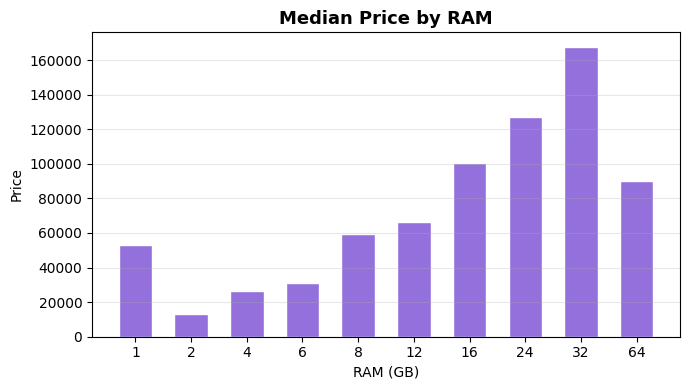

In [31]:
# --- Plot : Price vs RAM ---
plt.figure(figsize=(7, 4))
ram_price = df.groupby('Ram')['Price'].median().sort_index()
plt.bar(ram_price.index.astype(str), ram_price.values,
        color='mediumpurple', edgecolor='white', width=0.6)
plt.title('Median Price by RAM', fontsize=13, fontweight='bold')
plt.xlabel('RAM (GB)')
plt.ylabel('Price')
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

### 3.4 Column `Cpu`

In [32]:
print(df['Cpu'].str.split().str[0].unique())

['Intel' 'AMD' 'Samsung']


In [33]:
#------------------------------
# column FIVE just taking the brand name of the cpu
#------------------------------
df['CpuBrand'] = df['Cpu'].str.split().str[0]

In [34]:
# just to check
df.sample(10)

,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price,ScreenHeight,ScreenWidth,IPS,TouchScreen,CpuBrand
111,Dell,Ultrabook,13.3,Quad HD+ / Touchscreen 3200x1800,Intel Core i7 7560U 2.4GHz,8,256GB SSD,Intel Iris Plus Graphics 640,Windows 10,1.23kg,73473.1200,1800,3200,0,1,Intel
638,Lenovo,2 in 1 Convertible,13.3,IPS Panel Full HD / Touchscreen 1920x1080,Intel Core i7 7500U 2.7GHz,8,256GB SSD,Intel HD Graphics 620,Windows 10,1.37kg,93635.3376,1080,1920,1,1,Intel
798,Lenovo,2 in 1 Convertible,13.9,IPS Panel Full HD / Touchscreen 1920x1080,Intel Core i7 7500U 2.7GHz,8,256GB SSD,Intel HD Graphics 620,Windows 10,1.38kg,71874.7200,1080,1920,1,1,Intel
1099,Asus,Gaming,17.3,IPS Panel Full HD 1920x1080,Intel Core i7 6700HQ 2.6GHz,16,128GB SSD + 1TB HDD,Nvidia GeForce GTX 980M,Windows 10,4.3kg,122490.7200,1080,1920,1,0,Intel
238,Asus,Gaming,17.3,Full HD 1920x1080,Intel Core i7 7820HK 2.9GHz,32,512GB SSD + 1TB HDD,Nvidia GeForce GTX 1080,Windows 10,4.7kg,207259.2000,1080,1920,0,0,Intel
328,HP,Ultrabook,12.5,Full HD 1920x1080,Intel Core i7 7500U 2.7GHz,8,256GB SSD,Intel HD Graphics 620,Windows 10,1.26kg,71128.8000,1080,1920,0,0,Intel
102,Dell,Notebook,15.6,Full HD 1920x1080,Intel Core i5 8250U 1.6GHz,8,1TB HDD,AMD Radeon 520,Linux,2.2kg,34472.1600,1080,1920,0,0,Intel
1015,Toshiba,Notebook,13.3,1366x768,Intel Core i5 6200U 2.3GHz,8,256GB SSD,Intel HD Graphics 520,Windows 10,1.5kg,64468.8000,768,1366,0,0,Intel
1042,Toshiba,Notebook,15.6,IPS Panel Full HD 1920x1080,Intel Core i7 6500U 2.5GHz,16,256GB SSD,Nvidia GeForce 930M,Windows 10,2.4kg,75924.0000,1080,1920,1,0,Intel
912,Lenovo,Notebook,15.6,Full HD 1920x1080,Intel Core i7 7500U 2.7GHz,6,256GB SSD,Nvidia GeForce 940MX,Windows 10,2.2kg,42037.9200,1080,1920,0,0,Intel


In [35]:
# just checking before adding the column
print(df['Cpu'].str.split().apply(lambda x: " ".join(x[1:-1])))

0                       Core i5
1                       Core i5
2                 Core i5 7200U
3                       Core i7
4                       Core i5
                 ...           
1269              Core i7 6500U
1270              Core i7 6500U
1271              Core i7 6500U
1272    Celeron Dual Core N3050
1273              Core i7 6500U
Name: Cpu, Length: 1244, dtype: object


In [36]:
#------------------------------
# column SIX the series of the CPU
#------------------------------
df['CpuSeries'] = df['Cpu'].str.split().apply(lambda x: " ".join(x[1:-1]))

In [37]:
df.head()

,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price,ScreenHeight,ScreenWidth,IPS,TouchScreen,CpuBrand,CpuSeries
0,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37kg,71378.6832,1600,2560,1,0,Intel,Core i5
1,Apple,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34kg,47895.5232,900,1440,0,0,Intel,Core i5
2,HP,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8,256GB SSD,Intel HD Graphics 620,No OS,1.86kg,30636.0000,1080,1920,0,0,Intel,Core i5 7200U
3,Apple,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16,512GB SSD,AMD Radeon Pro 455,macOS,1.83kg,135195.3360,1800,2880,1,0,Intel,Core i7
4,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37kg,96095.8080,1600,2560,1,0,Intel,Core i5


In [38]:
#------------------------------
# column SEVEN, the GHz of the CPU taken from the last elemnt
#------------------------------
df['CpuGHz'] = df['Cpu'].str.split().str[-1].str.replace('GHz','').astype(float)

In [39]:
df.sample(10)

,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price,ScreenHeight,ScreenWidth,IPS,TouchScreen,CpuBrand,CpuSeries,CpuGHz
1008,HP,Notebook,14.0,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8,256GB SSD,Nvidia GeForce 930MX,Windows 10,1.64kg,55904.5728,1080,1920,0,0,Intel,Core i5 7200U,2.5
351,HP,Notebook,15.6,Full HD 1920x1080,Intel Core i7 7500U 2.7GHz,8,256GB SSD,Intel HD Graphics 620,Windows 10,1.84kg,69477.1200,1080,1920,0,0,Intel,Core i7 7500U,2.7
256,HP,Notebook,15.6,1366x768,AMD A6-Series A6-9220 2.5GHz,8,128GB SSD,AMD Radeon R4 Graphics,Windows 10,1.91kg,23757.5520,768,1366,0,0,AMD,A6-Series A6-9220,2.5
1222,HP,Notebook,15.6,Full HD 1920x1080,AMD A12-Series 9720P 2.7GHz,6,1TB HDD,AMD Radeon 530,Windows 10,2.1kg,28185.1200,1080,1920,0,0,AMD,A12-Series 9720P,2.7
1099,Asus,Gaming,17.3,IPS Panel Full HD 1920x1080,Intel Core i7 6700HQ 2.6GHz,16,128GB SSD + 1TB HDD,Nvidia GeForce GTX 980M,Windows 10,4.3kg,122490.7200,1080,1920,1,0,Intel,Core i7 6700HQ,2.6
429,Mediacom,2 in 1 Convertible,11.6,IPS Panel Full HD / Touchscreen 1920x1080,Intel Celeron Dual Core N3350 1.1GHz,4,32GB SSD,Intel HD Graphics 500,Windows 10,1.16kg,15930.7200,1080,1920,1,1,Intel,Celeron Dual Core N3350,1.1
416,Dell,Notebook,13.3,1366x768,Intel Core i3 6006U 2GHz,4,128GB SSD,Intel HD Graphics 520,Windows 10,1.65kg,36709.9200,768,1366,0,0,Intel,Core i3 6006U,2.0
331,Toshiba,Notebook,15.6,IPS Panel Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8,256GB SSD,Intel HD Graphics 620,Windows 10,2.0kg,50243.0400,1080,1920,1,0,Intel,Core i5 7200U,2.5
831,Lenovo,Ultrabook,14.0,IPS Panel Quad HD+ 2560x1440,Intel Core i7 6600U 2.6GHz,16,512GB SSD,Intel HD Graphics 520,Windows 10,1.1kg,111834.7200,1440,2560,1,0,Intel,Core i7 6600U,2.6
1074,Lenovo,Ultrabook,12.5,IPS Panel Full HD / Touchscreen 1920x1080,Intel Core i7 6500U 2.5GHz,8,256GB SSD,Intel HD Graphics 520,Windows 10,1.3kg,91294.7472,1080,1920,1,1,Intel,Core i7 6500U,2.5


###3.5. column `weight`

In [40]:
df['Weight'].unique()

array(['1.37kg', '1.34kg', '1.86kg', '1.83kg', '2.1kg', '2.04kg', '1.3kg',
       '1.6kg', '2.2kg', '0.92kg', '1.22kg', '2.5kg', '1.62kg', '1.91kg',
       '2.3kg', '1.35kg', '1.88kg', '1.89kg', '1.65kg', '2.71kg', '1.2kg',
       '1.44kg', '2.8kg', '2kg', '2.65kg', '2.77kg', '3.2kg', '1.49kg',
       '2.4kg', '2.13kg', '2.43kg', '1.7kg', '1.4kg', '1.8kg', '1.9kg',
       '3kg', '1.252kg', '2.7kg', '2.02kg', '1.63kg', '1.96kg', '1.21kg',
       '2.45kg', '1.25kg', '1.5kg', '2.62kg', '1.38kg', '1.58kg',
       '1.85kg', '1.23kg', '2.16kg', '2.36kg', '7.2kg', '2.05kg',
       '1.32kg', '1.75kg', '0.97kg', '2.56kg', '1.48kg', '1.74kg',
       '1.1kg', '1.56kg', '2.03kg', '1.05kg', '5.4kg', '4.4kg', '1.90kg',
       '1.29kg', '2.0kg', '1.95kg', '2.06kg', '1.12kg', '3.49kg',
       '3.35kg', '2.23kg', '?', '2.9kg', '4.42kg', '2.69kg', '2.37kg',
       '4.7kg', '3.6kg', '2.08kg', '4.3kg', '1.68kg', '1.41kg', '4.14kg',
       '2.18kg', '2.24kg', '2.67kg', '4.1kg', '2.14kg', '1.36kg',
       '

In [41]:
# one value contains '?', so I replaced it with nan first then converted the type of that column
# the imputed that value with the median because it's robust to outliers
df['Weight'] = df['Weight'].replace('?',np.nan)
df['Weight'] = df['Weight'].str.replace('kg','').astype(float)
df['Weight'] = df['Weight'].fillna(df['Weight'].median())

In [42]:
df.sample(10)

,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price,ScreenHeight,ScreenWidth,IPS,TouchScreen,CpuBrand,CpuSeries,CpuGHz
619,Acer,2 in 1 Convertible,11.6,IPS Panel Touchscreen 1366x768,Intel Celeron Quad Core N3160 1.6GHz,4,32GB Flash Storage,Intel HD Graphics 400,Chrome OS,1.25,20193.1200,768,1366,1,1,Intel,Celeron Quad Core N3160,1.6
876,Asus,Notebook,15.6,1366x768,Intel Pentium Quad Core N4200 1.1GHz,4,1TB HDD,Intel HD Graphics 505,Linux,2.00,21258.1872,768,1366,0,0,Intel,Pentium Quad Core N4200,1.1
83,Lenovo,Notebook,15.6,Full HD 1920x1080,AMD A6-Series 9220 2.5GHz,4,128GB SSD,AMD R4 Graphics,Windows 10,2.20,21258.7200,1080,1920,0,0,AMD,A6-Series 9220,2.5
348,Asus,2 in 1 Convertible,11.6,Touchscreen 1366x768,Intel Celeron Dual Core N3350 1.1GHz,4,32GB Flash Storage,Intel HD Graphics 500,Windows 10,1.50,19980.0000,768,1366,0,1,Intel,Celeron Dual Core N3350,1.1
609,Acer,Notebook,14.0,1366x768,Intel Pentium Quad Core N3710 1.6GHz,4,128GB Flash Storage,Intel HD Graphics 405,Windows 10,1.60,18594.7200,768,1366,0,0,Intel,Pentium Quad Core N3710,1.6
162,Dell,Notebook,15.6,Full HD 1920x1080,Intel Core i5 8250U 1.6GHz,8,256GB SSD,AMD Radeon 520,Windows 10,2.13,38787.8400,1080,1920,0,0,Intel,Core i5 8250U,1.6
741,Dell,Notebook,15.6,1366x768,Intel Core i3 6006U 2GHz,8,256GB SSD,Intel HD Graphics 520,Windows 10,2.00,35431.2000,768,1366,0,0,Intel,Core i3 6006U,2.0
1241,Asus,Ultrabook,13.3,Full HD 1920x1080,Intel Core i7 6500U 2.5GHz,8,256GB SSD,Intel HD Graphics 520,Windows 10,1.45,68198.4000,1080,1920,0,0,Intel,Core i7 6500U,2.5
470,HP,2 in 1 Convertible,13.3,IPS Panel 4K Ultra HD / Touchscreen 3840x2160,Intel Core i7 8550U 1.8GHz,8,512GB SSD,Intel UHD Graphics 620,Windows 10,1.29,106506.7200,2160,3840,1,1,Intel,Core i7 8550U,1.8
444,HP,Gaming,15.6,IPS Panel Full HD 1920x1080,Intel Core i7 7700HQ 2.8GHz,8,128GB SSD + 1TB HDD,Nvidia GeForce GTX 1050,Windows 10,2.20,58554.7200,1080,1920,1,0,Intel,Core i7 7700HQ,2.8


### 3.6. column `Memory`

In [43]:
df['Memory'].unique()

array(['128GB SSD', '128GB Flash Storage', '256GB SSD', '512GB SSD',
       '500GB HDD', '256GB Flash Storage', '1TB HDD',
       '128GB SSD +  1TB HDD', '256GB SSD +  256GB SSD',
       '64GB Flash Storage', '32GB Flash Storage', '256GB SSD +  1TB HDD',
       '256GB SSD +  2TB HDD', '32GB SSD', '2TB HDD', '64GB SSD',
       '1.0TB Hybrid', '512GB SSD +  1TB HDD', '1TB SSD',
       '256GB SSD +  500GB HDD', '128GB SSD +  2TB HDD',
       '512GB SSD +  512GB SSD', '16GB SSD', '16GB Flash Storage',
       '512GB SSD +  256GB SSD', '512GB SSD +  2TB HDD',
       '64GB Flash Storage +  1TB HDD', '180GB SSD', '1TB HDD +  1TB HDD',
       '32GB HDD', '1TB SSD +  1TB HDD', '?', '512GB Flash Storage',
       '128GB HDD', '240GB SSD', '8GB SSD', '508GB Hybrid', '1.0TB HDD',
       '512GB SSD +  1.0TB Hybrid', '256GB SSD +  1.0TB Hybrid'],
      dtype=object)

In [44]:
# the values above are in different scales and there are values with '?' and and some 1.0TB - 1TB
df['Memory'] = df['Memory'].str.replace('1TB','1024GB')
df['Memory'] = df['Memory'].str.replace('2TB','2048GB')
df['Memory'] = df['Memory'].str.replace('1.0TB','1024GB')
df['Memory'] = df['Memory'].replace('?', np.nan)
# i used the mode because the column is still an object (not a number)
df['Memory'] = df['Memory'].fillna(df['Memory'].mode()[0])

In [45]:
# check all good
df['Memory'].unique()

array(['128GB SSD', '128GB Flash Storage', '256GB SSD', '512GB SSD',
       '500GB HDD', '256GB Flash Storage', '1024GB HDD',
       '128GB SSD +  1024GB HDD', '256GB SSD +  256GB SSD',
       '64GB Flash Storage', '32GB Flash Storage',
       '256GB SSD +  1024GB HDD', '256GB SSD +  2048GB HDD', '32GB SSD',
       '2048GB HDD', '64GB SSD', '1024GB Hybrid',
       '512GB SSD +  1024GB HDD', '1024GB SSD', '256GB SSD +  500GB HDD',
       '128GB SSD +  2048GB HDD', '512GB SSD +  512GB SSD', '16GB SSD',
       '16GB Flash Storage', '512GB SSD +  256GB SSD',
       '512GB SSD +  2048GB HDD', '64GB Flash Storage +  1024GB HDD',
       '180GB SSD', '1024GB HDD +  1024GB HDD', '32GB HDD',
       '1024GB SSD +  1024GB HDD', '512GB Flash Storage', '128GB HDD',
       '240GB SSD', '8GB SSD', '508GB Hybrid',
       '512GB SSD +  1024GB Hybrid', '256GB SSD +  1024GB Hybrid'],
      dtype=object)

In [46]:
df.sample(10)

,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price,ScreenHeight,ScreenWidth,IPS,TouchScreen,CpuBrand,CpuSeries,CpuGHz
771,Samsung,2 in 1 Convertible,15.0,Full HD / Touchscreen 1920x1080,Intel Core i7 7500U 2.7GHz,16,256GB SSD,AMD Radeon 540,Windows 10,1.71,95850.7200,1080,1920,0,1,Intel,Core i7 7500U,2.7
54,Acer,Notebook,15.6,1366x768,Intel Core i3 7100U 2.4GHz,4,1024GB HDD,Intel HD Graphics 620,Windows 10,2.40,20459.5200,768,1366,0,0,Intel,Core i3 7100U,2.4
392,Acer,Notebook,15.6,IPS Panel 1366x768,Intel Core i5 8250U 1.6GHz,12,1024GB HDD,Nvidia GeForce MX130,Windows 10,2.20,36975.7872,768,1366,1,0,Intel,Core i5 8250U,1.6
72,Dell,Notebook,15.6,Full HD 1920x1080,Intel Core i7 8550U 1.8GHz,8,256GB SSD,AMD Radeon 530,Windows 10,2.20,46353.6000,1080,1920,0,0,Intel,Core i7 8550U,1.8
205,Lenovo,Gaming,15.6,Full HD 1920x1080,Intel Core i7 7700HQ 2.8GHz,16,512GB SSD,Nvidia GeForce GTX 1060,No OS,2.40,74485.4400,1080,1920,0,0,Intel,Core i7 7700HQ,2.8
90,Asus,Gaming,15.6,Full HD 1920x1080,AMD FX 9830P 3GHz,8,1024GB HDD,AMD Radeon RX 560,Windows 10,2.45,37242.7200,1080,1920,0,0,AMD,FX 9830P,3.0
562,HP,Ultrabook,13.3,IPS Panel Quad HD+ / Touchscreen 3200x1800,Intel Core M 6Y75 1.2GHz,16,512GB SSD,Intel HD Graphics 515,Windows 10,1.16,104695.2000,1800,3200,1,1,Intel,Core M 6Y75,1.2
470,HP,2 in 1 Convertible,13.3,IPS Panel 4K Ultra HD / Touchscreen 3840x2160,Intel Core i7 8550U 1.8GHz,8,512GB SSD,Intel UHD Graphics 620,Windows 10,1.29,106506.7200,2160,3840,1,1,Intel,Core i7 8550U,1.8
448,MSI,Gaming,15.6,Full HD 1920x1080,Intel Core i5 7300HQ 2.5GHz,8,256GB SSD,Nvidia GeForce GTX 1050,Windows 10,2.20,54757.9872,1080,1920,0,0,Intel,Core i5 7300HQ,2.5
643,Asus,Gaming,15.6,IPS Panel Full HD 1920x1080,Intel Core i7 7700HQ 2.8GHz,8,1024GB HDD,Nvidia GeForce GTX 1050 Ti,No OS,2.50,62284.3200,1080,1920,1,0,Intel,Core i7 7700HQ,2.8


## new four columns:

In [47]:
#------------------------------
# NEW COLUMNS 8,9,10,11 all of them 0 or 1
#------------------------------
df['SSD'] = df['Memory'].str.contains('SSD').astype(int)
df['HDD'] = df['Memory'].str.contains('HDD').astype(int)
df['Flash_Storage'] = df['Memory'].str.contains('Flash Storage').astype(int)
df['Hybrid'] = df['Memory'].str.contains('Hybrid').astype(int)

In [48]:
df.head()

,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,...,ScreenWidth,IPS,TouchScreen,CpuBrand,CpuSeries,CpuGHz,SSD,HDD,Flash_Storage,Hybrid
0,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37,...,2560,1,0,Intel,Core i5,2.3,1,0,0,0
1,Apple,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34,...,1440,0,0,Intel,Core i5,1.8,0,0,1,0
2,HP,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8,256GB SSD,Intel HD Graphics 620,No OS,1.86,...,1920,0,0,Intel,Core i5 7200U,2.5,1,0,0,0
3,Apple,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16,512GB SSD,AMD Radeon Pro 455,macOS,1.83,...,2880,1,0,Intel,Core i7,2.7,1,0,0,0
4,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37,...,2560,1,0,Intel,Core i5,3.1,1,0,0,0


In [49]:
def memsize(memory):
  total = 0
  for i in memory:
    total += int(i)
  return total

# just to remove (SSD|HDD|Hybrid|Flash Storage|GB)
df['MemoryGB'] = df['Memory'].str.replace(r'SSD|HDD|Hybrid|Flash Storage|GB','',regex=True)

# make a list containg the values for the storage
df['MemoryGB'] = df['MemoryGB'].str.strip().str.split('+')
# add the elements of the list to make total storage
df['MemoryGB'] = df['MemoryGB'].apply(memsize)
# check
df['MemoryGB']

,MemoryGB
0,128
1,128
2,256
3,512
4,256
...,...
1269,500
1270,128
1271,512
1272,64


In [50]:
df.sample(10)

,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,...,IPS,TouchScreen,CpuBrand,CpuSeries,CpuGHz,SSD,HDD,Flash_Storage,Hybrid,MemoryGB
405,Asus,Ultrabook,14.0,Full HD 1920x1080,Intel Core i7 7500U 2.7GHz,8,512GB SSD,Intel HD Graphics 620,Windows 10,1.10,...,0,0,Intel,Core i7 7500U,2.7,1,0,0,0,512
285,Acer,Notebook,15.6,IPS Panel Full HD / Touchscreen 1920x1080,Intel Core i7 7500U 2.7GHz,12,1024GB HDD,Intel HD Graphics 620,Windows 10,2.15,...,1,1,Intel,Core i7 7500U,2.7,0,1,0,0,1024
928,Dell,Notebook,15.6,1366x768,Intel Core i5 7200U 2.5GHz,4,1024GB HDD,Intel HD Graphics 620,Windows 10,2.18,...,0,0,Intel,Core i5 7200U,2.5,0,1,0,0,1024
664,MSI,Gaming,17.3,Full HD 1920x1080,Intel Core i7 7700HQ 2.8GHz,8,128GB SSD + 1024GB HDD,Nvidia GeForce GTX 1060,Windows 10,2.70,...,0,0,Intel,Core i7 7700HQ,2.8,1,1,0,0,1152
1216,Acer,Notebook,17.3,1600x900,Intel Core i3 6006U 2GHz,4,1024GB HDD,Nvidia GeForce 940MX,Windows 10,3.30,...,0,0,Intel,Core i3 6006U,2.0,0,1,0,0,1024
496,Lenovo,Notebook,15.6,Full HD 1920x1080,Intel Core i7 8550U 1.8GHz,8,256GB SSD,Intel UHD Graphics 620,Windows 10,2.17,...,0,0,Intel,Core i7 8550U,1.8,1,0,0,0,256
756,HP,Notebook,15.6,IPS Panel Full HD 1920x1080,Intel Core i5 7300HQ 2.5GHz,8,128GB SSD + 1024GB HDD,Nvidia GeForce GTX 1050,Windows 10,2.20,...,1,0,Intel,Core i5 7300HQ,2.5,1,1,0,0,1152
1144,HP,2 in 1 Convertible,13.3,Touchscreen 2560x1440,Intel Core i7 6600U 2.6GHz,8,256GB SSD,Intel HD Graphics 520,Windows 10,1.48,...,0,1,Intel,Core i7 6600U,2.6,1,0,0,0,256
14,Apple,Ultrabook,12.0,IPS Panel Retina Display 2304x1440,Intel Core M m3 1.2GHz,8,256GB SSD,Intel HD Graphics 615,macOS,0.92,...,1,0,Intel,Core M m3,1.2,1,0,0,0,256
250,Dell,2 in 1 Convertible,15.6,IPS Panel Full HD / Touchscreen 1920x1080,Intel Core i7 8550U 1.8GHz,8,1024GB HDD,Intel UHD Graphics 620,Windows 10,2.08,...,1,1,Intel,Core i7 8550U,1.8,0,1,0,0,1024


## 3.7. column `GPU`

In [51]:
df['Gpu'].str.split().str[0].unique()

array(['Intel', 'AMD', 'Nvidia', 'ARM'], dtype=object)

In [52]:
#---------------------------------
# column 12 - just store the brand of the GPU
#---------------------------------
df['Gpu_Brand'] = df['Gpu'].str.split().str[0]

In [53]:
df.head()

,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,...,TouchScreen,CpuBrand,CpuSeries,CpuGHz,SSD,HDD,Flash_Storage,Hybrid,MemoryGB,Gpu_Brand
0,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37,...,0,Intel,Core i5,2.3,1,0,0,0,128,Intel
1,Apple,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34,...,0,Intel,Core i5,1.8,0,0,1,0,128,Intel
2,HP,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8,256GB SSD,Intel HD Graphics 620,No OS,1.86,...,0,Intel,Core i5 7200U,2.5,1,0,0,0,256,Intel
3,Apple,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16,512GB SSD,AMD Radeon Pro 455,macOS,1.83,...,0,Intel,Core i7,2.7,1,0,0,0,512,AMD
4,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37,...,0,Intel,Core i5,3.1,1,0,0,0,256,Intel


In [54]:
# apply function just to store the cpu type
#---------------------------------
# Column 13
#---------------------------------
def cpu_family(cpu):
    cpu = cpu.lower()

    if "core i3" in cpu:
        return "Core i3"
    elif "core i5" in cpu:
        return "Core i5"
    elif "core i7" in cpu:
        return "Core i7"
    elif "core i9" in cpu:
        return "Core i9"
    elif "xeon" in cpu:
        return "Xeon"
    elif "ryzen" in cpu:
        return "Ryzen"
    elif "celeron" in cpu:
        return "Celeron"
    elif "pentium" in cpu:
        return "Pentium"
    elif "atom" in cpu:
        return "Atom"
    elif "a12" in cpu:
        return "A12"
    elif "a10" in cpu:
        return "A10"
    elif "a9" in cpu:
        return "A9"
    elif "a8" in cpu:
        return "A8"
    elif "a6" in cpu:
        return "A6"
    elif "a4" in cpu:
        return "A4"
    elif "e-series" in cpu:
        return "E-Series"
    elif "fx" in cpu:
        return "FX"
    elif "cortex" in cpu:
        return "Cortex"
    else:
        return "Other"

df["CpuFamily"] = df["CpuSeries"].apply(cpu_family)

In [55]:
#-----------------------------
# column 14 to store the type of the GPU
#-----------------------------
def gpu_series(gpu):
    gpu = gpu.lower()

    if "rtx" in gpu:
        return "RTX"
    elif "gtx" in gpu:
        return "GTX"
    elif "mx" in gpu:
        return "MX"
    elif "quadro" in gpu:
        return "Quadro"
    elif "rx" in gpu:
        return "RX"
    elif "radeon" in gpu:
        return "Radeon"
    elif "firepro" in gpu:
        return "FirePro"
    elif "iris plus" in gpu:
        return "Iris Plus"
    elif "iris" in gpu:
        return "Iris"
    elif "uhd" in gpu:
        return "UHD"
    elif "hd" in gpu:
        return "HD"
    elif "graphics" in gpu:
        return "Graphics"
    elif "mali" in gpu:
        return "Mali"
    else:
        return "Other"

df["GpuSeries"] = df["Gpu"].apply(gpu_series)

# 4. Encoding

In [56]:
# one-hot-encoding to object columns as int
df = pd.get_dummies(df,columns=["TypeName","OpSys","CpuBrand","Gpu_Brand","CpuFamily","GpuSeries"], dtype=int) # "Company",

In [57]:
df.head()

,Company,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,Weight,Price,ScreenHeight,...,GpuSeries_HD,GpuSeries_Iris,GpuSeries_Iris Plus,GpuSeries_MX,GpuSeries_Mali,GpuSeries_Other,GpuSeries_Quadro,GpuSeries_RX,GpuSeries_Radeon,GpuSeries_UHD
0,Apple,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8,128GB SSD,Intel Iris Plus Graphics 640,1.37,71378.6832,1600,...,0,0,1,0,0,0,0,0,0,0
1,Apple,13.3,1440x900,Intel Core i5 1.8GHz,8,128GB Flash Storage,Intel HD Graphics 6000,1.34,47895.5232,900,...,1,0,0,0,0,0,0,0,0,0
2,HP,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8,256GB SSD,Intel HD Graphics 620,1.86,30636.0000,1080,...,1,0,0,0,0,0,0,0,0,0
3,Apple,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16,512GB SSD,AMD Radeon Pro 455,1.83,135195.3360,1800,...,0,0,0,0,0,0,0,0,1,0
4,Apple,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8,256GB SSD,Intel Iris Plus Graphics 650,1.37,96095.8080,1600,...,0,0,1,0,0,0,0,0,0,0


In [58]:
# drop these columns, because I already extracted the features from them (except company because i will encode it later)
df.select_dtypes(include='object').columns

Index(['Company', 'ScreenResolution', 'Cpu', 'Memory', 'Gpu', 'CpuSeries'], dtype='object')

In [59]:
df.drop(columns=['ScreenResolution', 'Cpu', 'Memory', 'Gpu', 'CpuSeries'],inplace=True)

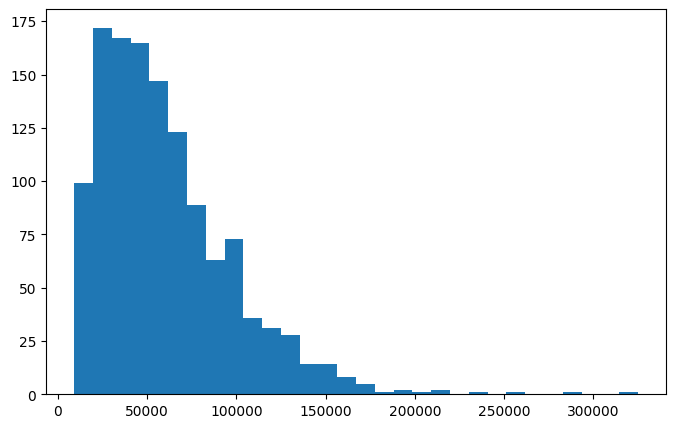

In [60]:
# skweness to the left, i will fix later
plt.figure(figsize=(8,5))
plt.hist(df['Price'],bins=30)
plt.show()

In [61]:
df.head()

,Company,Inches,Ram,Weight,Price,ScreenHeight,ScreenWidth,IPS,TouchScreen,CpuGHz,...,GpuSeries_HD,GpuSeries_Iris,GpuSeries_Iris Plus,GpuSeries_MX,GpuSeries_Mali,GpuSeries_Other,GpuSeries_Quadro,GpuSeries_RX,GpuSeries_Radeon,GpuSeries_UHD
0,Apple,13.3,8,1.37,71378.6832,1600,2560,1,0,2.3,...,0,0,1,0,0,0,0,0,0,0
1,Apple,13.3,8,1.34,47895.5232,900,1440,0,0,1.8,...,1,0,0,0,0,0,0,0,0,0
2,HP,15.6,8,1.86,30636.0000,1080,1920,0,0,2.5,...,1,0,0,0,0,0,0,0,0,0
3,Apple,15.4,16,1.83,135195.3360,1800,2880,1,0,2.7,...,0,0,0,0,0,0,0,0,1,0
4,Apple,13.3,8,1.37,96095.8080,1600,2560,1,0,3.1,...,0,0,1,0,0,0,0,0,0,0


Correlation heatmap

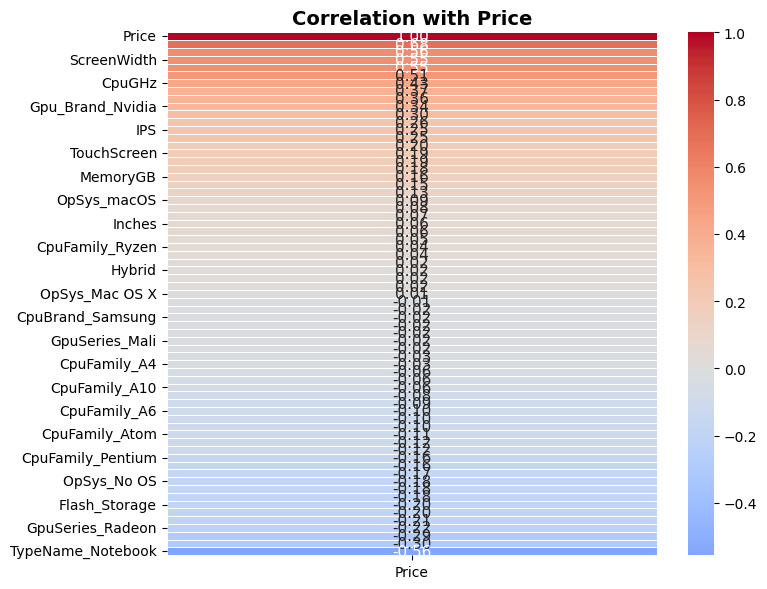

In [62]:
plt.figure(figsize=(8, 6))

num_df = df.select_dtypes(include=np.number)
corr_with_price = num_df.corr()[['Price']].sort_values('Price', ascending=False)

sns.heatmap(
    corr_with_price,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    linewidths=0.5,
    annot_kws={"size": 11}
)
plt.title('Correlation with Price', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# 5. Split the data

In [63]:
# split target from the data
X = df.drop(columns='Price',axis=1)
y = df['Price']

In [64]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42 ,shuffle=True)

# log to fix the skewness
y_train = np.log(y_train)
y_test = np.log(y_test)

In [65]:
!pip install category_encoders

In [66]:
# binary encoder to avoid having 19 new columns
from category_encoders import BinaryEncoder

encoder = BinaryEncoder(cols=['Company'])

X_train = encoder.fit_transform(X_train)
X_test = encoder.transform(X_test)

In [67]:
# scale
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Scaling is regiured here, because Linear regression a distance based model, but with random forest regressor it's not required

In [68]:
# pca
from sklearn.decomposition import PCA
pca = PCA(n_components=0.95)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

In [69]:
print('number of components:',pca.n_components_)
print('explained variance:',pca.explained_variance_ratio_)

number of components: 44
explained variance: [0.09751392 0.0761693  0.06156512 0.05175576 0.03807568 0.03437212
 0.03270577 0.02750108 0.02508495 0.02402027 0.02320643 0.02265862
 0.02050375 0.02005822 0.01962526 0.01874207 0.01794092 0.01732363
 0.01679647 0.01618455 0.0160205  0.01533729 0.01512181 0.01480481
 0.01462027 0.01456984 0.01437201 0.01418024 0.01397594 0.01383828
 0.01307279 0.01277366 0.01218574 0.01180296 0.01086304 0.01053428
 0.01031879 0.00990264 0.00974827 0.00924746 0.00900102 0.00835021
 0.00818286 0.00761694]


the copmonents explian 95% of the variance, it reduses number of features.. it made the model worse

In [70]:
print("Before PCA:", X_train.shape[1])
print("After PCA:", X_train_pca.shape[1])

Before PCA: 71
After PCA: 44


In [71]:
print(df.columns.tolist())

['Company', 'Inches', 'Ram', 'Weight', 'Price', 'ScreenHeight', 'ScreenWidth', 'IPS', 'TouchScreen', 'CpuGHz', 'SSD', 'HDD', 'Flash_Storage', 'Hybrid', 'MemoryGB', 'TypeName_2 in 1 Convertible', 'TypeName_Gaming', 'TypeName_Netbook', 'TypeName_Notebook', 'TypeName_Ultrabook', 'TypeName_Workstation', 'OpSys_Android', 'OpSys_Chrome OS', 'OpSys_Linux', 'OpSys_Mac OS X', 'OpSys_No OS', 'OpSys_Windows 10', 'OpSys_Windows 10 S', 'OpSys_Windows 7', 'OpSys_macOS', 'CpuBrand_AMD', 'CpuBrand_Intel', 'CpuBrand_Samsung', 'Gpu_Brand_AMD', 'Gpu_Brand_ARM', 'Gpu_Brand_Intel', 'Gpu_Brand_Nvidia', 'CpuFamily_A10', 'CpuFamily_A12', 'CpuFamily_A4', 'CpuFamily_A6', 'CpuFamily_A8', 'CpuFamily_A9', 'CpuFamily_Atom', 'CpuFamily_Celeron', 'CpuFamily_Core i3', 'CpuFamily_Core i5', 'CpuFamily_Core i7', 'CpuFamily_Cortex', 'CpuFamily_E-Series', 'CpuFamily_FX', 'CpuFamily_Other', 'CpuFamily_Pentium', 'CpuFamily_Ryzen', 'CpuFamily_Xeon', 'GpuSeries_FirePro', 'GpuSeries_GTX', 'GpuSeries_Graphics', 'GpuSeries_HD', '

# 6. Modeling

##1st model (Linear Regression)

In [72]:
from sklearn.linear_model import LinearRegression
line_model = LinearRegression().fit(X_train_pca,y_train)
line_pred = line_model.predict(X_test_pca)

In [73]:
from sklearn.metrics import (mean_absolute_error, mean_squared_error, r2_score)
MAE = mean_absolute_error(y_test, line_pred)
MSE = mean_squared_error(y_test, line_pred)
RMSE = np.sqrt(MSE)
R2 = r2_score(y_test, line_pred)

In [74]:
print(f'MAE: {MAE}\nMSE: {MSE}\nRMSE: {RMSE}\nR2: {R2}')

MAE: 0.19725066611521969
MSE: 0.06529263225198147
RMSE: 0.2555242302639448
R2: 0.8148265349233261


# 2nd model XGBRegression (the best)

In [75]:
from xgboost import XGBRegressor

xgb = XGBRegressor(random_state=42).fit(X_train_scaled, y_train)
xgb_pred = xgb.predict(X_test_scaled)

print("MAE:", mean_absolute_error(y_test, xgb_pred))
print("MSE:", mean_squared_error(y_test, xgb_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, xgb_pred)))
print("R2:", r2_score(y_test, xgb_pred))

MAE: 0.148479914872196
MSE: 0.042329227010145076
RMSE: 0.2057406790358802
R2: 0.879952004243973


# 3rd Random Forest

In [76]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    max_depth=300
).fit(X_train, y_train)
rf_pred = rf.predict(X_test)

print("MAE:", mean_absolute_error(y_test, rf_pred))
print("MSE:", mean_squared_error(y_test, rf_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, rf_pred)))
print("R2:", r2_score(y_test, rf_pred))

MAE: 0.15655109362886666
MSE: 0.04536488378690006
RMSE: 0.21299033730876163
R2: 0.8713427161091981


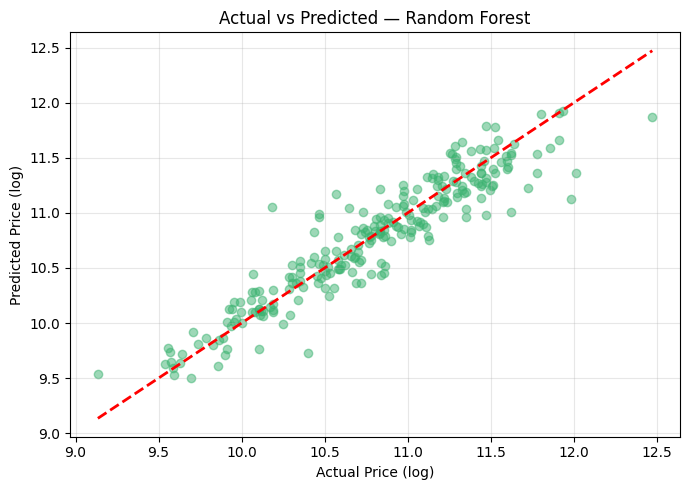

In [77]:
plt.figure(figsize=(7,5))
plt.scatter(y_test, rf.predict(X_test), alpha=0.5, color='mediumseagreen')
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()], 'r--', linewidth=2)
plt.xlabel('Actual Price (log)')
plt.ylabel('Predicted Price (log)')
plt.title('Actual vs Predicted — Random Forest')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Cross Validation for XGBRegressor

In [78]:
from sklearn.model_selection import cross_val_score
scores = cross_val_score(
    xgb,
    X_train,
    y_train,
    cv=5,
    scoring="r2"
)

print(scores)
print(scores.mean())

[0.86326482 0.89074065 0.85319444 0.88177315 0.91048436]
0.8798914838752786


## EXTRA (tune parameters with Randomized Search)

In [79]:
from xgboost import XGBRegressor
from sklearn.model_selection import RandomizedSearchCV

xgb = XGBRegressor(objective="reg:squarederror", random_state=42)

param_dist = {"n_estimators": [100, 200, 300, 500],
    "max_depth": [3, 5, 7, 9],"learning_rate": [0.01, 0.05, 0.1, 0.2],
    "subsample": [0.6, 0.8, 1.0],
    "colsample_bytree": [0.6, 0.8, 1.0],
    "gamma": [0, 0.1, 0.3, 0.5],
    "min_child_weight": [1, 3, 5]
}

random_search = RandomizedSearchCV(estimator=xgb, param_distributions=param_dist,
    n_iter=30, scoring="r2", cv=5, random_state=42, n_jobs=-1, verbose=2
).fit(X_train_scaled, y_train)

Fitting 5 folds for each of 30 candidates, totalling 150 fits


In [80]:
print(random_search.best_params_)
print(random_search.best_score_)

{'subsample': 0.8, 'n_estimators': 500, 'min_child_weight': 3, 'max_depth': 9, 'learning_rate': 0.01, 'gamma': 0, 'colsample_bytree': 0.6}
0.8924488243501789


## Final results:

In [81]:
best_xgb = random_search.best_estimator_

y_pred = best_xgb.predict(X_test_scaled)

from sklearn.metrics import r2_score

print("Test R2:", r2_score(y_test, y_pred))

Test R2: 0.899046412159569


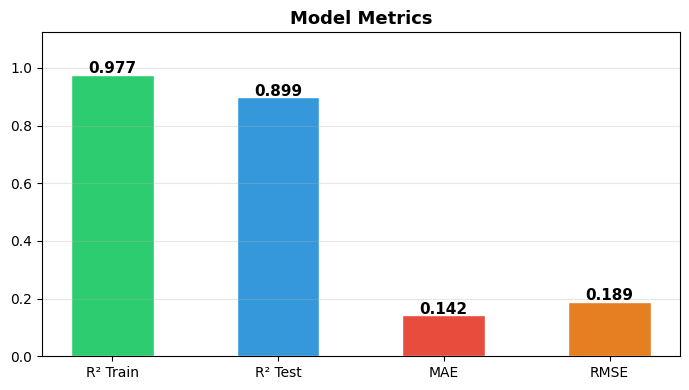

In [82]:
# --- Plot : Metrics ---
plt.figure(figsize=(7, 4))
metrics = {
    'R² Train': r2_score(y_train, best_xgb.predict(X_train_scaled)),
    'R² Test' : r2_score(y_test,  best_xgb.predict(X_test_scaled)),
    'MAE'     : mean_absolute_error(y_test, best_xgb.predict(X_test_scaled)),
    'RMSE'    : np.sqrt(mean_squared_error(y_test, best_xgb.predict(X_test_scaled)))
}
colors = ['#2ecc71', '#3498db', '#e74c3c', '#e67e22']
bars = plt.bar(metrics.keys(), metrics.values(), color=colors, width=0.5, edgecolor='white')
for bar, val in zip(bars, metrics.values()):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
             f'{val:.3f}', ha='center', fontsize=11, fontweight='bold')
plt.title('Model Metrics', fontsize=13, fontweight='bold')
plt.ylim(0, max(metrics.values()) * 1.15)
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

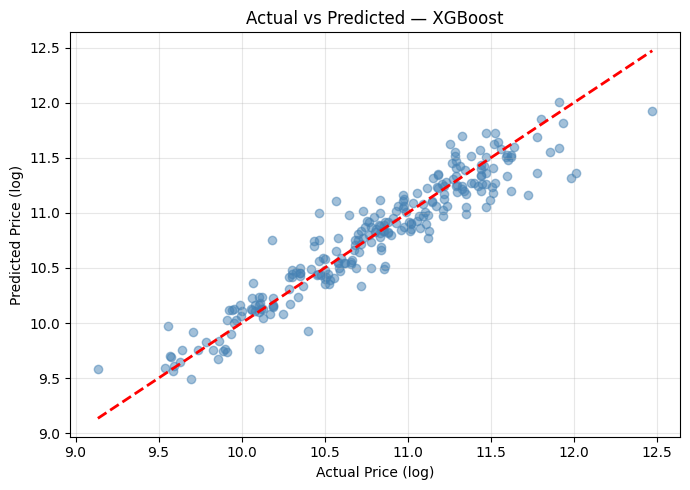

In [83]:
plt.figure(figsize=(7,5))
plt.scatter(y_test, best_xgb.predict(X_test_scaled), alpha=0.5, color='steelblue')
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()], 'r--', linewidth=2)
plt.xlabel('Actual Price (log)')
plt.ylabel('Predicted Price (log)')
plt.title('Actual vs Predicted — XGBoost')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Summary 📖
---
Which model performed best❓

Both `RandomForestRegressor` and `XGBRegressor` performed well, but `XGBRegressor` performed slightly better.

🥇 Achiving **89.9%** in **R2** score using `RandomizedSearch` to tune the hyperparameters

---

What I would do in the future❔

try other methods in Cleaning the data and Feature engineering and experiment with hyperparameters 🧪

spend more time on the data ⏰